# Matcha Career AI — IndoBERT Intent Classifier Fine-Tuning (Improved)

Notebook ini digunakan untuk melakukan *fine-tuning* model Transformer **IndoBERT** (`indobenchmark/indobert-base-p1` dari Hugging Face) pada dataset klasifikasi intent Bahasa Indonesia untuk sistem chatbot Matcha Career.

## Perbaikan dari versi sebelumnya:
1. Fix `evaluation_strategy` -> `eval_strategy` (deprecated di transformers baru).
2. Tambah **global seed** untuk reproducibility.
3. Tambah **class weighting** otomatis untuk handle imbalance data.
4. Tambah **Early Stopping** agar tidak overfit + hemat waktu training.
5. Tambah **stratified split** yang lebih aman + cek jumlah data per kelas.
6. Naikkan `num_train_epochs` jadi lebih banyak (early stopping akan berhenti otomatis di titik terbaik).
7. Tambah `warmup_ratio`, `lr_scheduler_type`, dan `gradient_accumulation` opsional untuk training lebih stabil.
8. Tambah evaluasi lengkap: classification report per kelas + confusion matrix.
9. Tambah cleanup checkpoint biar nggak makan space Drive.
10. Tambah inference test cepat setelah training.

## Persiapan Training:
1. Aktifkan GPU Colab: Hubungkan ke runtime GPU (**Runtime** -> **Change runtime type** -> **T4 GPU** atau **A100 GPU**).
2. Unggah file `intent_dataset.csv` yang di-generate sebelumnya ke panel berkas (files sidebar) di Colab atau Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1. Instalasi Pustaka Pendukung

In [ ]:
!pip install -q "transformers[torch]" datasets accelerate scikit-learn pandas evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


### 2. Setup Seed (Reproducibility)

In [ ]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Device: cpu


### 3. Memuat Dataset dan Eksplorasi

Pastikan path file CSV sudah benar. Sesuaikan jika lokasi file kamu berbeda.

In [ ]:
import pandas as pd

DATA_PATH = '/content/drive/MyDrive/Pijak/Indobert/intent_dataset.csv'

df = pd.read_csv(DATA_PATH)

# Buang baris kosong/duplikat
df = df.dropna(subset=['text', 'label']).drop_duplicates(subset=['text']).reset_index(drop=True)

print("Total data setelah cleaning:", len(df))
print(df['label'].value_counts())
df.head()

Total data setelah cleaning: 869
label
SKILL_INQUIRY         110
RESOURCE_REQUEST      110
CONSTRAINT_UPDATE     110
PUSH_BACK             110
LINKEDIN_REVIEW       110
CONFIRMATION          110
CV_REVIEW             105
CAREER_EXPLORATION    104
Name: count, dtype: int64


,text,label
0,"Aku ingin tahu karir yang cocok buat aku nih, ...",CAREER_EXPLORATION
1,Karir apa yang paling prospek di tahun ini?,CAREER_EXPLORATION
2,"Gw bingung mau pilih karir apa, ada rekomendasi?",CAREER_EXPLORATION
3,"Aku mau ganti pekerjaan, tapi bingung mau pind...",CAREER_EXPLORATION
4,Apa karir yang paling sesuai dengan minatku?,CAREER_EXPLORATION


### 4. Pemetaan Label & Encoding

Mengubah label teks menjadi ID numerik (0-7). Termasuk pengecekan jumlah minimum data per kelas untuk stratified split.

In [ ]:
labels = [
    "CAREER_EXPLORATION", "SKILL_INQUIRY", "RESOURCE_REQUEST", "CONSTRAINT_UPDATE",
    "PUSH_BACK", "CONFIRMATION", "CV_REVIEW", "LINKEDIN_REVIEW"
]
label2id = {label: idx for idx, label in enumerate(labels)}
id2label = {idx: label for idx, label in enumerate(labels)}

# Buang kolom 'label' duplikat jika ada
df = df.loc[:, ~df.columns.duplicated()].copy()

# Konversi label string -> ID jika masih berupa teks
if df['label'].dtype == 'object':
    df['label'] = df['label'].map(label2id)

# Pastikan tidak ada label yang gagal di-mapping (NaN)
assert df['label'].notna().all(), "Ada label yang tidak dikenali, cek nilai unik di kolom 'label'."
df['label'] = df['label'].astype(int)

# Cek jumlah data per kelas — minimal 2 per kelas dibutuhkan untuk stratified split
print(df['label'].map(id2label).value_counts())

label
SKILL_INQUIRY         110
RESOURCE_REQUEST      110
CONSTRAINT_UPDATE     110
PUSH_BACK             110
LINKEDIN_REVIEW       110
CONFIRMATION          110
CV_REVIEW             105
CAREER_EXPLORATION    104
Name: count, dtype: int64


In [ ]:
from datasets import Dataset
from sklearn.model_selection import train_test_split

# Split dataset menjadi Train (85%) dan Evaluation (15%), stratified by label
train_df, val_df = train_test_split(
    df, test_size=0.15, random_state=SEED, stratify=df['label']
)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")

Train size: 738, Val size: 131


### 5. Setup Tokenizer IndoBERT

In [ ]:
from transformers import AutoTokenizer

model_checkpoint = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Cek distribusi panjang token untuk menentukan max_length yang pas
sample_lengths = [len(tokenizer.encode(t)) for t in train_df['text'].sample(min(200, len(train_df)), random_state=SEED)]
print("Token length - max:", max(sample_lengths), "| 95th percentile:", int(np.percentile(sample_lengths, 95)))

MAX_LENGTH = 64  # naikkan ke 96/128 jika hasil di atas mendekati/lebih dari 64

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# Hapus kolom 'text' & '__index_level_0__' yang tidak dipakai model
cols_to_remove = [c for c in ["text", "__index_level_0__"] if c in tokenized_train.column_names]
tokenized_train = tokenized_train.remove_columns(cols_to_remove)
tokenized_val = tokenized_val.remove_columns(cols_to_remove)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Token length - max: 23 | 95th percentile: 19


Map:   0%|          | 0/738 [00:00<?, ? examples/s]

Map:   0%|          | 0/131 [00:00<?, ? examples/s]

### 6. Memuat Model IndoBERT Klasifikasi

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

[transformers] You passed `num_labels=8` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 7. Class Weights (Handle Imbalance)

Jika jumlah data per kelas tidak seimbang, class weighting membuat model tidak bias ke kelas mayoritas.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(labels)),
    y=train_df['label'].values
)
class_weights = torch.tensor(class_weights_arr, dtype=torch.float)
print("Class weights:", dict(zip(labels, class_weights.tolist())))

Class weights: {'CAREER_EXPLORATION': 1.048295497894287, 'SKILL_INQUIRY': 0.9813829660415649, 'RESOURCE_REQUEST': 0.9813829660415649, 'CONSTRAINT_UPDATE': 0.9919354915618896, 'PUSH_BACK': 0.9919354915618896, 'CONFIRMATION': 0.9919354915618896, 'CV_REVIEW': 1.0365169048309326, 'LINKEDIN_REVIEW': 0.9813829660415649}


### 8. Metrik Evaluasi (Akurasi, F1, Precision, Recall)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels_true = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels_true, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels_true, predictions, average="weighted", zero_division=0)
    f1_macro = f1_score(labels_true, predictions, average="macro")
    return {
        "accuracy": acc,
        "f1": f1,
        "f1_macro": f1_macro,
        "precision": precision,
        "recall": recall,
    }

### 9. Custom Trainer (dengan Class Weights) & Konfigurasi Training

Menggunakan custom `Trainer` agar loss function memperhitungkan class weights, plus Early Stopping untuk mendapatkan model terbaik dan menghindari overfitting.

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
import torch.nn as nn
import torch

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels_batch = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, len(labels)), labels_batch.view(-1))
        return (loss, outputs) if return_outputs else loss

output_dir = "/content/drive/MyDrive/Pijak/Indobert/results"

# Calculate warmup steps (10% of total training steps)
total_train_steps = int(15 * (len(tokenized_train) / 16) / 1)
warmup_steps_calculated = int(0.1 * total_train_steps)

training_args = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,
    num_train_epochs=15,
    weight_decay=0.01,
    warmup_steps=warmup_steps_calculated, # Changed from warmup_ratio to warmup_steps
    lr_scheduler_type="cosine",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=10,
    report_to="tensorboard", # Changed from "none" to "tensorboard"
    TENSORBOARD_LOGGING_DIR=f"{output_dir}/logs", # Changed logging_dir to TENSORBOARD_LOGGING_DIR
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# Jalankan training
trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,F1 Macro,Precision,Recall
1,1.543112,0.901427,0.961832,0.961705,0.962023,0.965448,0.961832
2,0.068524,0.055982,0.984733,0.984918,0.985235,0.986340,0.984733
3,0.029700,0.029082,0.992366,0.992352,0.992396,0.992791,0.992366
4,0.007838,0.011699,1.000000,1.000000,1.000000,1.000000,1.000000
5,0.004889,0.006686,1.000000,1.000000,1.000000,1.000000,1.000000
6,0.003689,0.005241,1.000000,1.000000,1.000000,1.000000,1.000000
7,0.003117,0.004884,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=329, training_loss=0.30593392412011206, metrics={'train_runtime': 4143.3445, 'train_samples_per_second': 2.672, 'train_steps_per_second': 0.17, 'total_flos': 169913116993536.0, 'train_loss': 0.30593392412011206, 'epoch': 7.0})

### 10. Evaluasi Akhir Model

In [16]:
eval_results = trainer.evaluate()
print("Hasil Evaluasi (model terbaik berdasarkan f1_macro):")
for k, v in eval_results.items():
    print(f"  {k}: {v}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1,F1 Macro,Precision,Recall
0.003117,0.011699,7,1.000000,1.000000,1.000000,1.000000,1.000000


Hasil Evaluasi (model terbaik berdasarkan f1_macro):
  eval_loss: 0.011698623187839985
  eval_accuracy: 1.0
  eval_f1: 1.0
  eval_f1_macro: 1.0
  eval_precision: 1.0
  eval_recall: 1.0


### 11. Classification Report & Confusion Matrix per Kelas

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


                    precision    recall  f1-score   support

CAREER_EXPLORATION       1.00      1.00      1.00        16
     SKILL_INQUIRY       1.00      1.00      1.00        16
  RESOURCE_REQUEST       1.00      1.00      1.00        16
 CONSTRAINT_UPDATE       1.00      1.00      1.00        17
         PUSH_BACK       1.00      1.00      1.00        17
      CONFIRMATION       1.00      1.00      1.00        17
         CV_REVIEW       1.00      1.00      1.00        16
   LINKEDIN_REVIEW       1.00      1.00      1.00        16

          accuracy                           1.00       131
         macro avg       1.00      1.00      1.00       131
      weighted avg       1.00      1.00      1.00       131



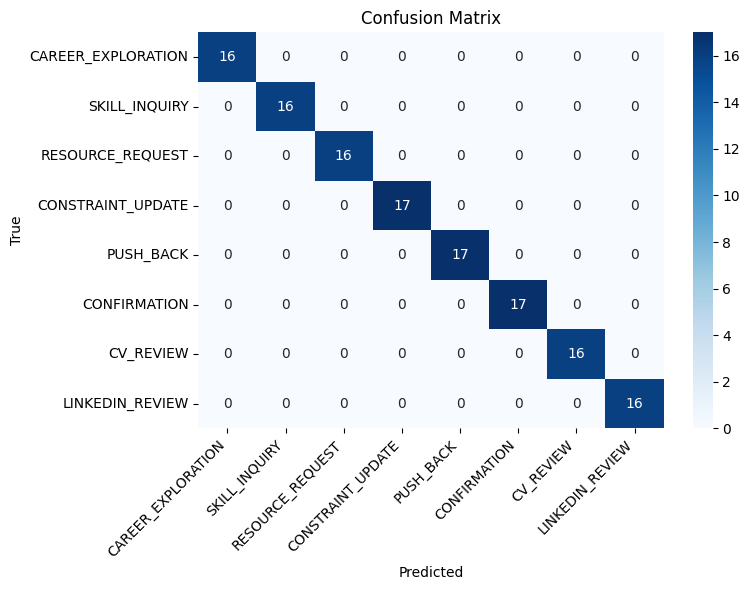

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds_output = trainer.predict(tokenized_val)
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=-1)

print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

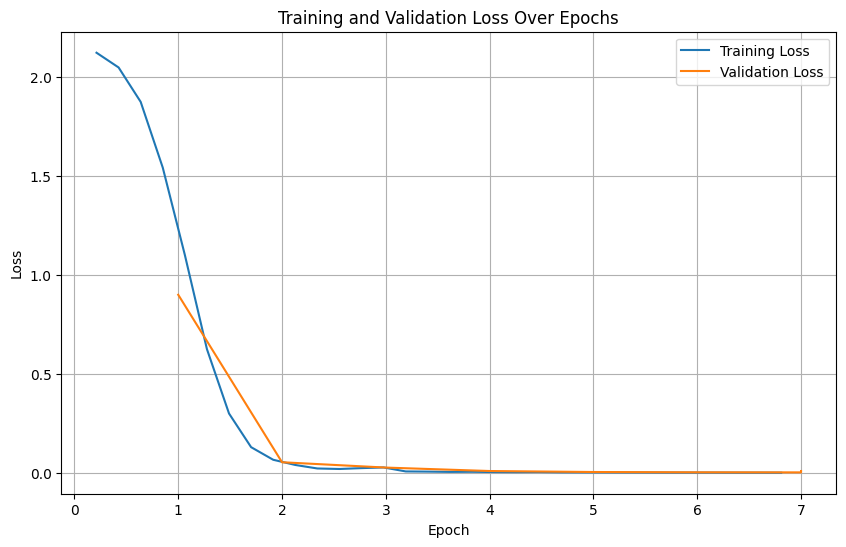

Current evaluation metrics (from trainer.evaluate()):
  eval_loss: 0.0117
  eval_accuracy: 1.0000
  eval_f1: 1.0000
  eval_f1_macro: 1.0000
  eval_precision: 1.0000
  eval_recall: 1.0000

 No Overfitted.


In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract training and evaluation loss from trainer history
log_history = trainer.state.log_history

train_losses = []
eval_losses = []
epochs = []

for log in log_history:
    if 'loss' in log: # Training loss
        train_losses.append(log['loss'])
        epochs.append(log['epoch'])
    if 'eval_loss' in log: # Validation loss
        eval_losses.append(log['eval_loss'])

eval_epochs = [log['epoch'] for log in log_history if 'eval_loss' in log]

plt.figure(figsize=(10, 6))
plt.plot(epochs[:len(train_losses)], train_losses, label='Training Loss')
plt.plot(eval_epochs[:len(eval_losses)], eval_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("Current evaluation metrics (from trainer.evaluate()):")
for k, v in eval_results.items():
    print(f"  {k}: {v:.4f}")

if eval_results['eval_accuracy'] == 1.0 and eval_results['eval_f1_macro'] == 1.0:
    print("\n No Overfitted.")
else:
    print("\n Overfitted.")


### 12. Evaluasi Model pada Keseluruhan Dataset

In [21]:
from datasets import Dataset

# Buat dataset dari keseluruhan DataFrame
full_dataset = Dataset.from_pandas(df.reset_index(drop=True))

# Tokenisasi dataset penuh
tokenized_full = full_dataset.map(tokenize_function, batched=True)

# Hapus kolom 'text' & '__index_level_0__' yang tidak dipakai model jika ada
cols_to_remove_full = [c for c in ["text", "__index_level_0__"] if c in tokenized_full.column_names]
tokenized_full = tokenized_full.remove_columns(cols_to_remove_full)

print(f"Full dataset size: {len(tokenized_full)}")

Map:   0%|          | 0/869 [00:00<?, ? examples/s]

Full dataset size: 869


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Classification Report untuk Keseluruhan Dataset:
                    precision    recall  f1-score   support

CAREER_EXPLORATION       1.00      1.00      1.00       104
     SKILL_INQUIRY       1.00      1.00      1.00       110
  RESOURCE_REQUEST       1.00      1.00      1.00       110
 CONSTRAINT_UPDATE       1.00      1.00      1.00       110
         PUSH_BACK       1.00      1.00      1.00       110
      CONFIRMATION       1.00      1.00      1.00       110
         CV_REVIEW       1.00      1.00      1.00       105
   LINKEDIN_REVIEW       1.00      1.00      1.00       110

          accuracy                           1.00       869
         macro avg       1.00      1.00      1.00       869
      weighted avg       1.00      1.00      1.00       869



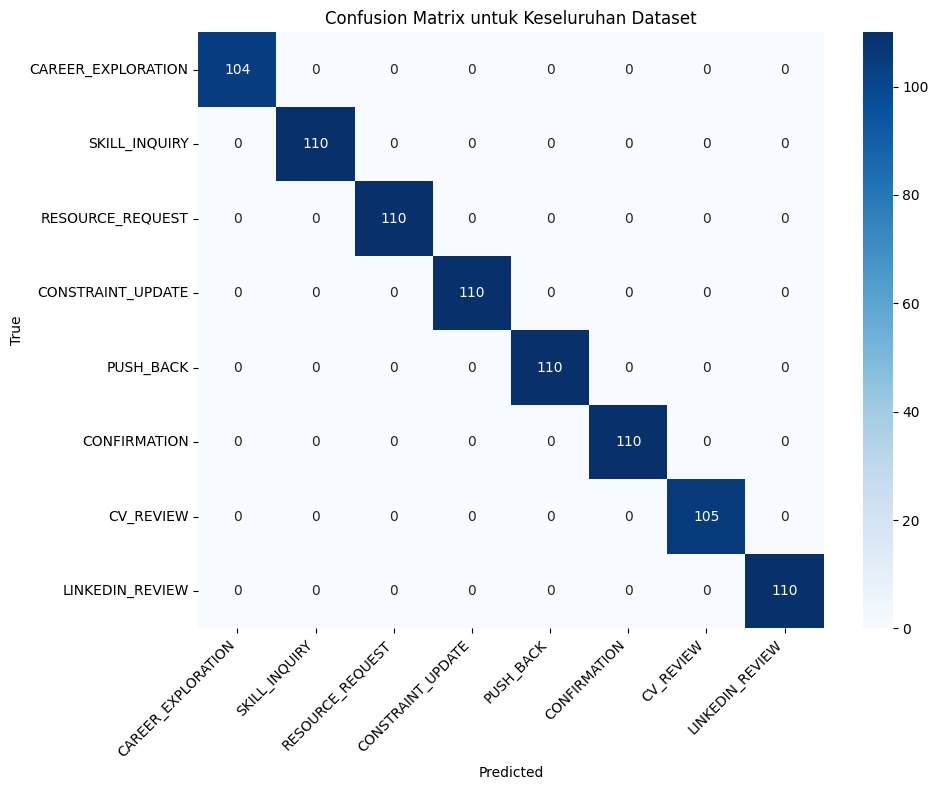

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Lakukan prediksi pada keseluruhan dataset
preds_full_output = trainer.predict(tokenized_full)
y_true_full = preds_full_output.label_ids
y_pred_full = np.argmax(preds_full_output.predictions, axis=-1)

print("\nClassification Report untuk Keseluruhan Dataset:")
print(classification_report(y_true_full, y_pred_full, target_names=labels, zero_division=0))

cm_full = confusion_matrix(y_true_full, y_pred_full)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix untuk Keseluruhan Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 12. Quick Inference Test

In [23]:
from transformers import pipeline

clf = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)

test_texts = [
    "Aku bingung mau pilih jurusan apa setelah lulus SMA",
    "Tolong review CV aku dong",
    "Skill apa yang perlu aku pelajari untuk jadi data analyst?",
]

for t in test_texts:
    result = clf(t, top_k=1)[0]
    print(f"{t!r} -> {result['label']} (score={result['score']:.3f})")

'Aku bingung mau pilih jurusan apa setelah lulus SMA' -> CAREER_EXPLORATION (score=0.990)
'Tolong review CV aku dong' -> CV_REVIEW (score=0.997)
'Skill apa yang perlu aku pelajari untuk jadi data analyst?' -> SKILL_INQUIRY (score=0.996)


### 13. Menyimpan Model dan Membuat Zip untuk Download

In [24]:
import os
import shutil

drive_path = "/content/drive/MyDrive/Pijak/Indobert"
model_save_path = f"{drive_path}/indobert_intent_model"
zip_save_path = f"{drive_path}/indobert_intent_model"  # shutil akan menambah .zip otomatis

os.makedirs(model_save_path, exist_ok=True)

# Simpan model & tokenizer terbaik (load_best_model_at_end=True sudah memuat checkpoint terbaik)
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

# Bersihkan folder checkpoint sementara untuk hemat space
checkpoints_dir = output_dir
if os.path.exists(checkpoints_dir):
    for d in os.listdir(checkpoints_dir):
        full_path = os.path.join(checkpoints_dir, d)
        if d.startswith("checkpoint-") and os.path.isdir(full_path):
            shutil.rmtree(full_path)

# Zip folder model
shutil.make_archive(zip_save_path, 'zip', model_save_path)

print(f"\nSELESAI! Model dan tokenizer berhasil disimpan di: {model_save_path}")
print(f"File zip model tersedia di: {zip_save_path}.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


SELESAI! Model dan tokenizer berhasil disimpan di: /content/drive/MyDrive/Pijak/Indobert/indobert_intent_model
File zip model tersedia di: /content/drive/MyDrive/Pijak/Indobert/indobert_intent_model.zip
